# 02 — Skills Demand

Which technical skills appear most in German IT job postings. Examines the most frequently required skills, how they cluster by job family, co-occurrence patterns between skills, and distinctions between required and nice-to-have competencies.

In [2]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [3]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, heatmap
from analysis.filters import explode_json_col

df.head(3)

,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## Top 20 Technical Skills

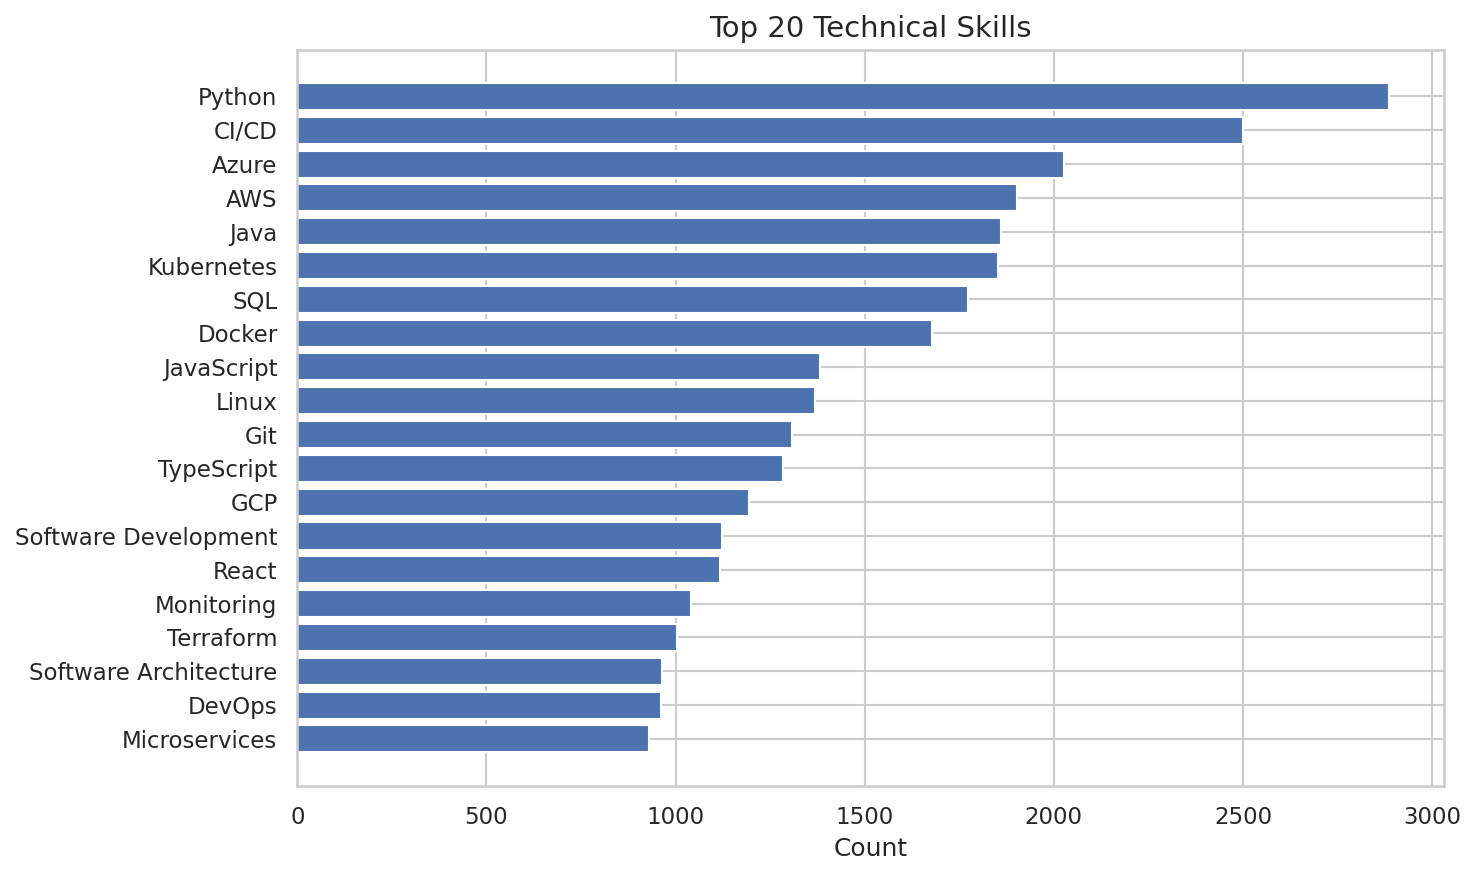

In [4]:
skills_exploded = explode_json_col(df, "technical_skills")
horizontal_bar(
    skills_exploded["technical_skills"],
    "Top 20 Technical Skills",
    top_n=20,
    save_as="02_top_skills.png",
)

## Skills by Job Family (heatmap)

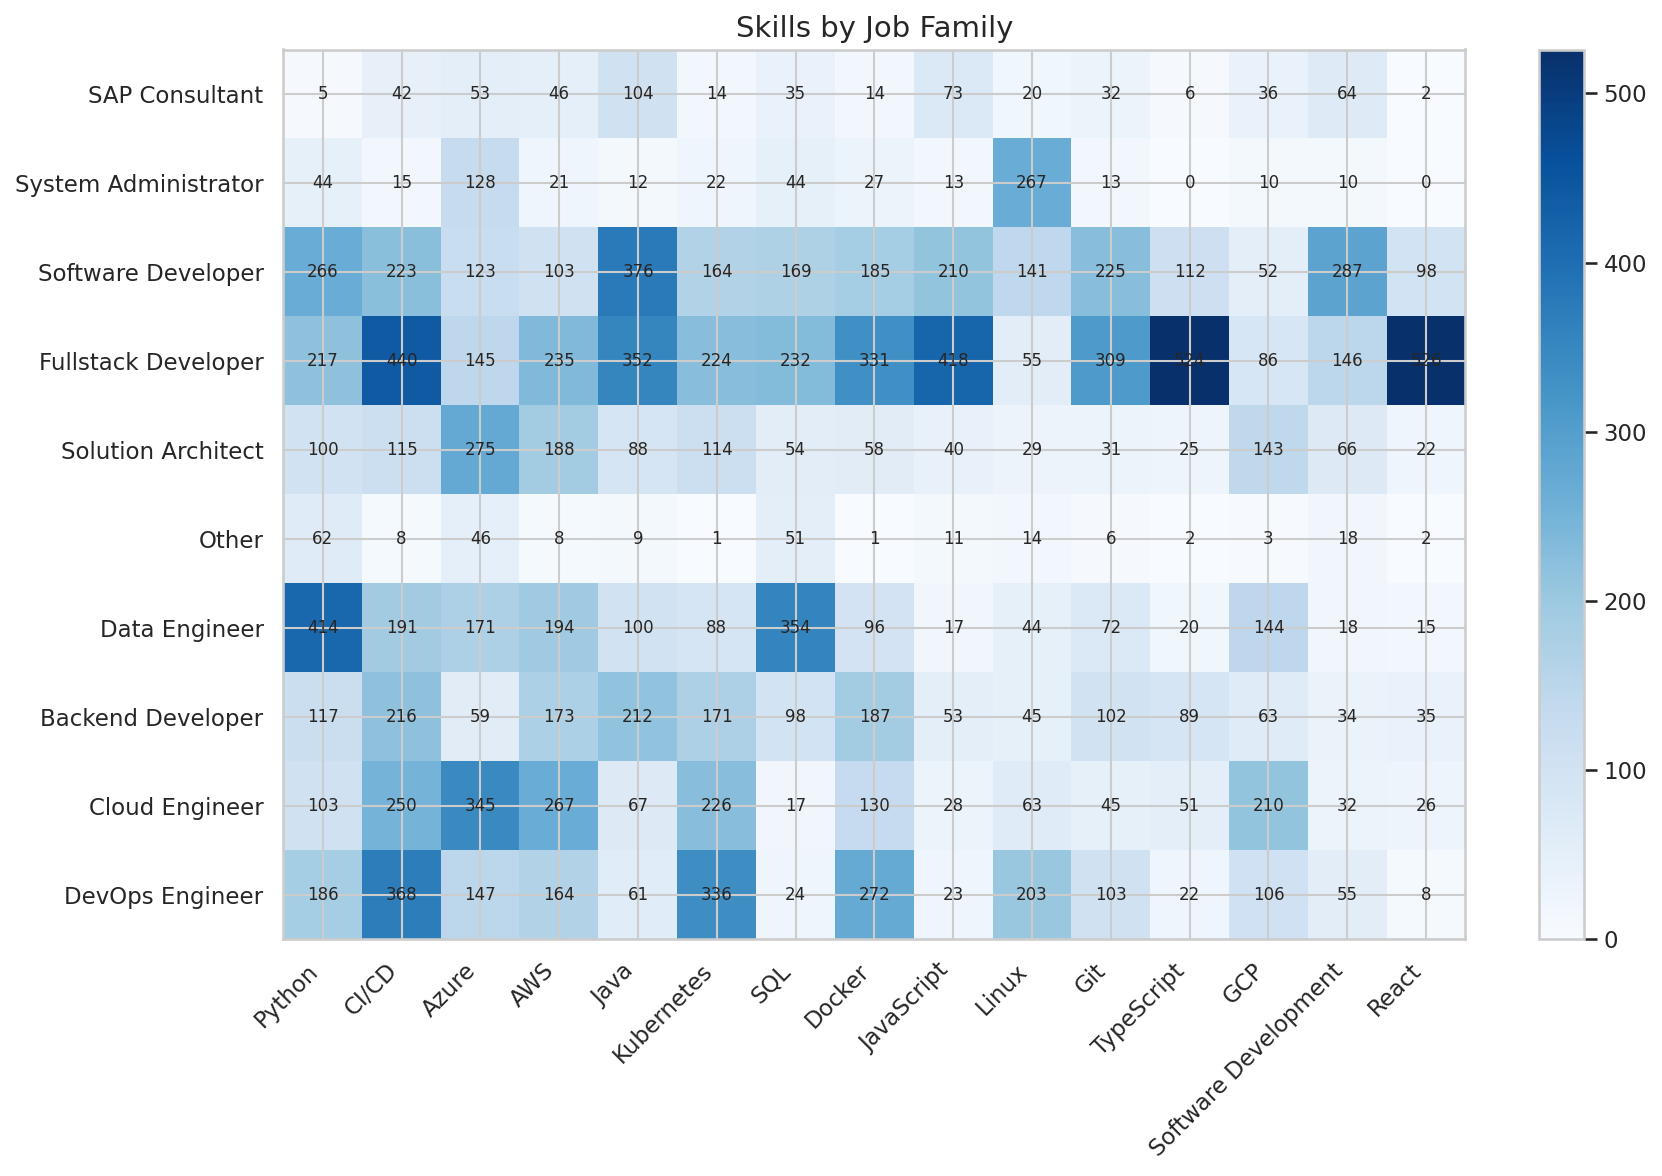

In [5]:
import pandas as pd

top_families = df["job_family"].value_counts().head(10).index.tolist()
top_skills = skills_exploded["technical_skills"].value_counts().head(15).index.tolist()

skill_family_df = skills_exploded[
    skills_exploded["job_family"].isin(top_families)
    & skills_exploded["technical_skills"].isin(top_skills)
]
pivot = (
    skill_family_df.groupby(["job_family", "technical_skills"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(index=top_families, columns=top_skills, fill_value=0)
heatmap(pivot, "Skills by Job Family", save_as="02_skill_family.png")

## Co-occurrence Matrix

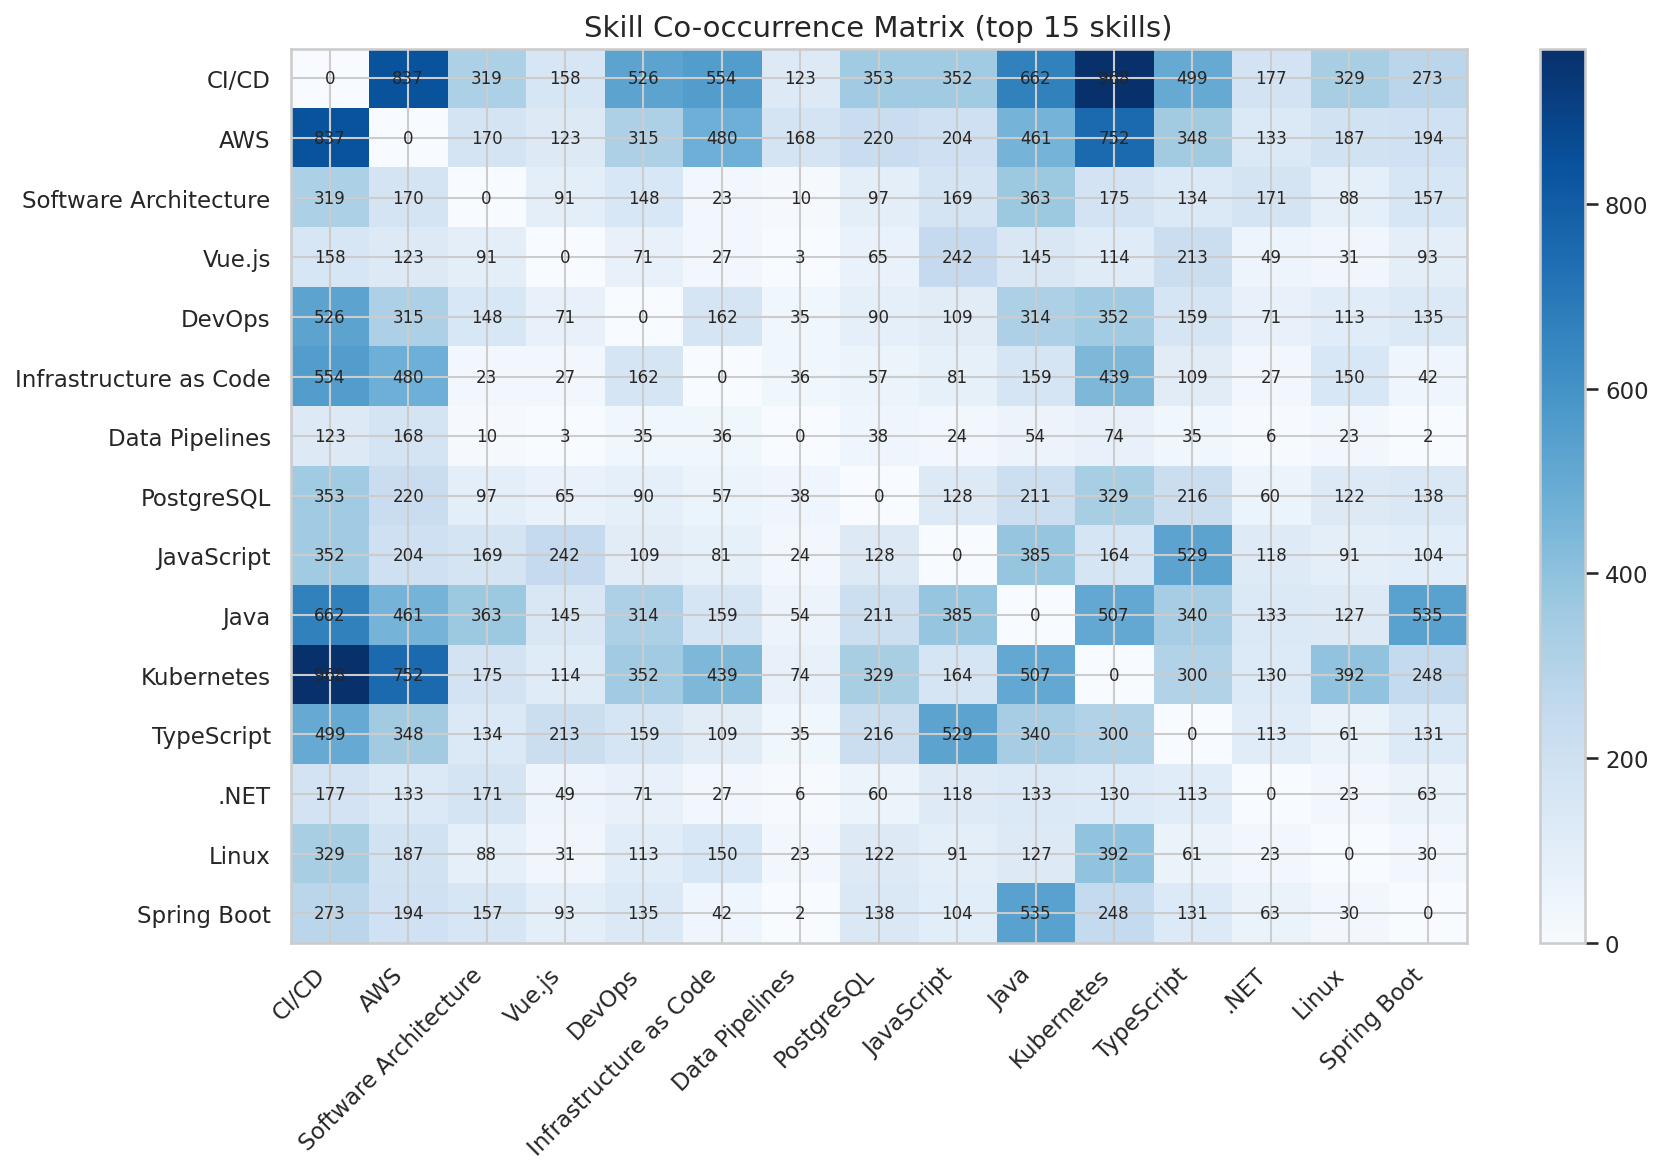

In [6]:
import json
from collections import Counter

co_counter: Counter = Counter()
for val in df["technical_skills"]:
    try:
        skills = json.loads(str(val))
        if isinstance(skills, list) and len(skills) > 1:
            skills = sorted(set(skills))
            for i in range(len(skills)):
                for j in range(i + 1, len(skills)):
                    pair = (skills[i], skills[j])
                    co_counter[pair] += 1
    except (json.JSONDecodeError, TypeError):
        pass

top_co_skills = list(
    {s for pair, _ in co_counter.most_common(100) for s in pair}
)[:15]
co_matrix = pd.DataFrame(0, index=top_co_skills, columns=top_co_skills)
for (s1, s2), count in co_counter.items():
    if s1 in top_co_skills and s2 in top_co_skills:
        co_matrix.loc[s1, s2] = count
        co_matrix.loc[s2, s1] = count

heatmap(co_matrix, "Skill Co-occurrence Matrix (top 15 skills)", save_as="02_cooccurrence.png")

## Required vs Nice-to-Have

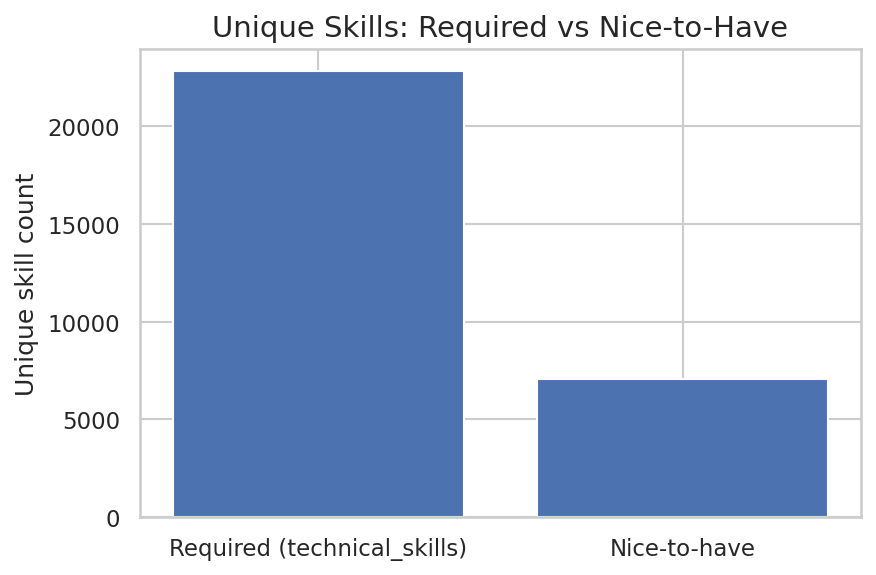

In [7]:
import matplotlib.pyplot as plt

req_skills = explode_json_col(df, "technical_skills")["technical_skills"].nunique()
nice_skills = explode_json_col(df, "nice_to_have_skills")["nice_to_have_skills"].nunique()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Required (technical_skills)", "Nice-to-have"], [req_skills, nice_skills])
ax.set_title("Unique Skills: Required vs Nice-to-Have")
ax.set_ylabel("Unique skill count")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "02_req_vs_nice.png", dpi=150)